# 04 — Random Walk
**Week 2 | Mathematical Foundations for RL**

Random walks appear everywhere in RL — from the way an agent explores to the theoretical analysis
of TD learning. They also give great intuition about variance in stochastic processes.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(7)

## 1. Simple 1D Random Walk
At each step: move +1 (right) or -1 (left) with equal probability.

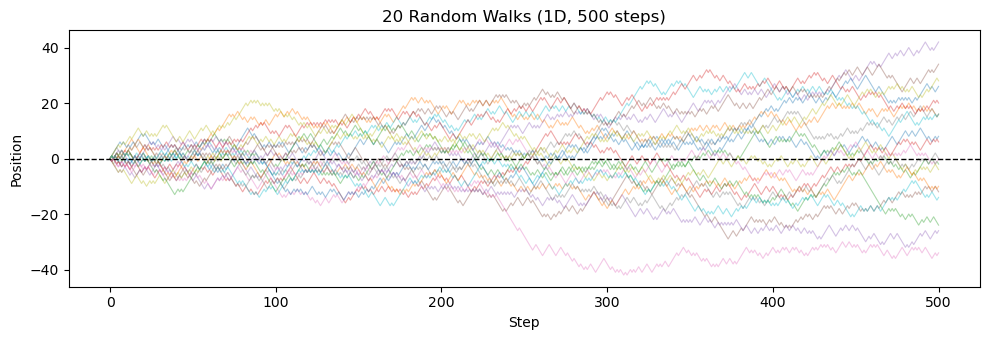

In [7]:
def random_walk_1d(n_steps, p_right=0.5):
    steps = np.where(np.random.rand(n_steps) < p_right, 1, -1)
    return np.concatenate([[0], np.cumsum(steps)])

n_steps = 500
fig, ax = plt.subplots(figsize=(10, 3.5))
for i in range(20):
    walk = random_walk_1d(n_steps)
    ax.plot(walk, alpha=0.4, linewidth=0.8)
ax.axhline(0, color='black', linewidth=1, linestyle='--')
ax.set_xlabel('Step'); ax.set_ylabel('Position')
ax.set_title('20 Random Walks (1D, 500 steps)')
plt.tight_layout(); plt.show()

In [8]:
def	walk_until_boundary(target=20,	max_steps=1_000_000):
				pos	=	0
				for	_	in	range(max_steps):
								pos	+=	np.random.choice([-1,	1])
								if	abs(pos)	>=	target:
												return	pos
				return	pos
results	=	np.array([walk_until_boundary(20)	for	_	in	range(2000)])
frac_plus		=	(results	==	20).mean()
frac_minus	=	(results	==	-20).mean()
print(f"Ended	at	+20:	{frac_plus:.1%}			Ended	at	-20:	 {frac_minus:.1%}")

Ended	at	+20:	49.6%			Ended	at	-20:	 50.3%


## 2. Distribution of Positions at Time t
At time t, position X_t ~ N(0, t) — variance grows linearly with time.

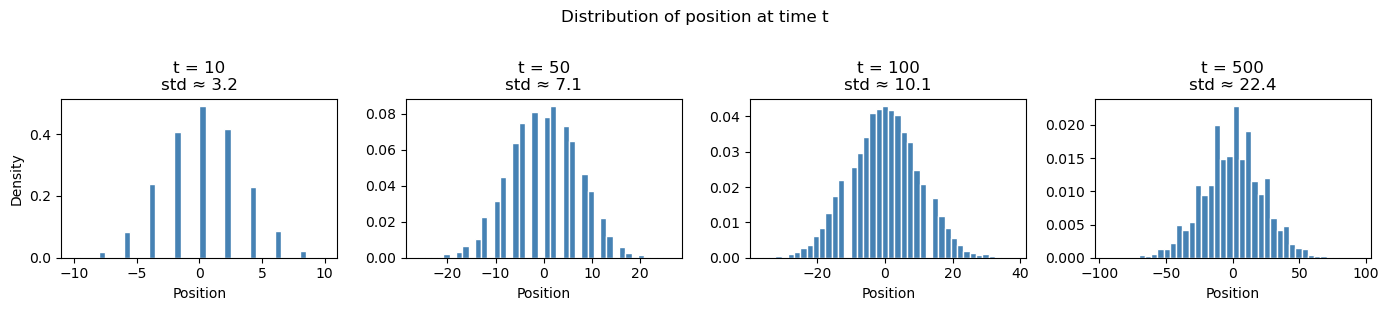

Theoretical std = sqrt(t): ['10→3.2', '50→7.1', '100→10.0', '500→22.4']


In [9]:
checkpoints = [10, 50, 100, 500]
n_walks = 10_000
fig, axes = plt.subplots(1, len(checkpoints), figsize=(14, 3), sharey=False)

for ax, t in zip(axes, checkpoints):
    positions = [random_walk_1d(t)[-1] for _ in range(n_walks)]
    ax.hist(positions, bins=40, color='steelblue', edgecolor='white', density=True)
    ax.set_title(f't = {t}\nstd ≈ {np.std(positions):.1f}')
    ax.set_xlabel('Position')

axes[0].set_ylabel('Density')
plt.suptitle('Distribution of position at time t', y=1.02)
plt.tight_layout(); plt.show()
print("Theoretical std = sqrt(t):", [f"{t}→{t**0.5:.1f}" for t in checkpoints])

## 3. Biased Random Walk
What if the agent has a preference? (p_right > 0.5)

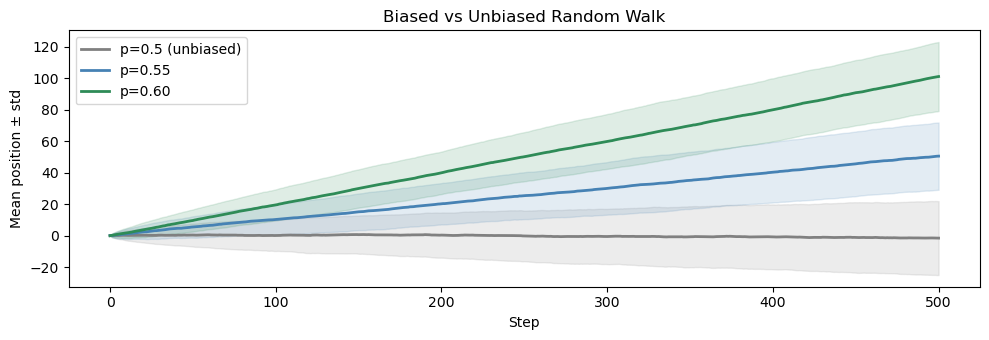

In [10]:
fig, ax = plt.subplots(figsize=(10, 3.5))
for p, color, label in [(0.5,'gray','p=0.5 (unbiased)'), (0.55,'steelblue','p=0.55'), (0.6,'seagreen','p=0.60')]:
    walks = np.array([random_walk_1d(500, p) for _ in range(500)])
    mean_walk = walks.mean(axis=0)
    std_walk  = walks.std(axis=0)
    x = np.arange(501)
    ax.plot(mean_walk, color=color, linewidth=2, label=label)
    ax.fill_between(x, mean_walk-std_walk, mean_walk+std_walk, alpha=0.15, color=color)
ax.set_xlabel('Step'); ax.set_ylabel('Mean position ± std')
ax.set_title('Biased vs Unbiased Random Walk')
ax.legend(); plt.tight_layout(); plt.show()

## 4. First Passage Time
How long until the walk reaches position +10 for the first time?

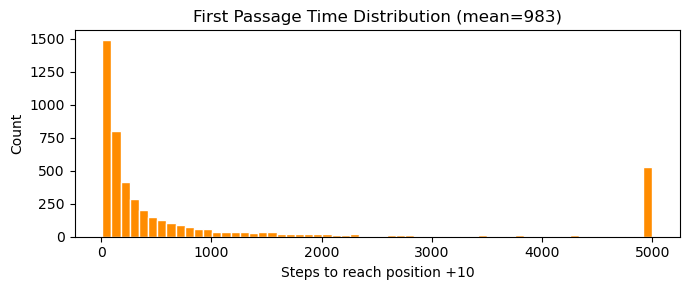

In [11]:
def first_passage_time(target=10, max_steps=5000):
    pos = 0
    for t in range(1, max_steps+1):
        pos += np.random.choice([-1, 1])
        if pos >= target:
            return t
    return max_steps  # didn't reach target

fpt = [first_passage_time(10) for _ in range(5000)]
plt.figure(figsize=(7, 3))
plt.hist(fpt, bins=60, color='darkorange', edgecolor='white')
plt.xlabel('Steps to reach position +10'); plt.ylabel('Count')
plt.title(f'First Passage Time Distribution (mean={np.mean(fpt):.0f})')
plt.tight_layout(); plt.show()

## ✅ Exercises
1. Modify the 1D walk to stop when it hits +20 or -20. What fraction of walks end at +20 vs -20?
2. Simulate a **2D random walk** (move up/down/left/right). Plot 5 trajectories on an x-y grid.
3. **Challenge**: implement the classic '5-state random walk' from Sutton & Barto Example 6.2. States A–E, terminal states at each end. Compute true state values analytically and verify empirically.

C:\Users\arinu\AppData\Local\Temp\ipykernel_19304\2495086054.py:13: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.legend(fontsize=8);	plt.axis('equal');	plt.tight_layout();
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


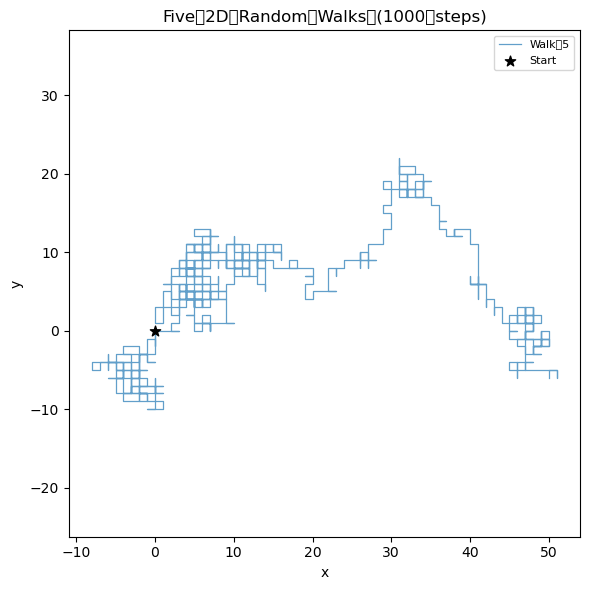

In [12]:
def	random_walk_2d(n_steps):
				dirs	=	np.array([[1,0],	[-1,0],	[0,1],	[0,-1]])			#	R,	L,	U,	D
				steps	=	dirs[np.random.randint(0,	4,	size=n_steps)]
				return	np.vstack([[0,	0],	np.cumsum(steps,	axis=0)])
plt.figure(figsize=(6,	6))
for	i	in	range(5):
	w =	random_walk_2d(1000)
plt.plot(w[:,	0],	w[:,	1],	alpha=0.7,	linewidth=0.9,	
label=f'Walk	{i+1}')
plt.scatter([0],	[0],	color='black',	zorder=5,	s=60,	marker='*',	
label='Start')
plt.xlabel('x');	plt.ylabel('y');	plt.title('Five	2D	Random	Walks	(1000	steps)')
plt.legend(fontsize=8);	plt.axis('equal');	plt.tight_layout();	
plt.show()

State:       ['A', 'B', 'C', 'D', 'E']
True V:      [0.1667 0.3333 0.5    0.6667 0.8333]
Empirical V: [0.1709 0.3372 0.4967 0.6695 0.8354]
✅ Matches analytical values


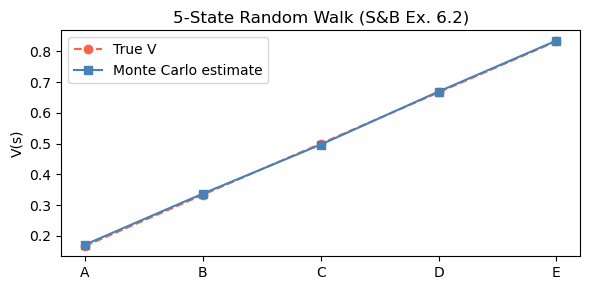

In [13]:
# States A–E = 0–4, start at C (2). Terminals: left of A (reward 0), right of E (reward 1).
# Analytical true values: V(s) = P(exit right | start s) = (s+1)/6
true_V = np.array([1, 2, 3, 4, 5]) / 6

def episode(start):
    s = start
    while True:
        s += np.random.choice([-1, 1])
        if s < 0:  return 0.0   # exited left
        if s > 4:  return 1.0   # exited right

n_episodes = 20_000
#est_V = np.array([np.mean([episode(s) for s in range(n_episodes)[:0] or [s]*0]) for s in range(5)])
est_V = np.array([np.mean([episode(s) for _ in range(n_episodes)]) for s in range(5)])

print("State:      ", ['A','B','C','D','E'])
print("True V:     ", np.round(true_V, 4))
print("Empirical V:", np.round(est_V, 4))
assert np.allclose(est_V, true_V, atol=0.02), "Empirical values off!"
print("✅ Matches analytical values")

plt.figure(figsize=(6, 3))
plt.plot(true_V, 'o--', color='tomato', label='True V')
plt.plot(est_V, 's-', color='steelblue', label='Monte Carlo estimate')
plt.xticks(range(5), ['A','B','C','D','E'])
plt.ylabel('V(s)'); plt.title('5-State Random Walk (S&B Ex. 6.2)')
plt.legend(); plt.tight_layout(); plt.show()

Ans 1) ~50/50	(within	sampling	noise).	The	walk	is	symmetric
and	starts	at	0,	equidistant	from	both	boundaries	—	the	gambler’s
ruin	probability	of	hitting	+20	first	is	exactly	0.5.

Ans 2) 	Five	tangled	paths	spreading	from	the	origin.	Typical
distance	from	origin	after	t	steps	≈	√t.

Ans 3) Empirical	V	matches	[0.167,	0.333,	0.5,	0.667,	0.833]
within	±0.01.	Why	analytical	V	=	(s+1)/6:	the	value	is	the	probability
of	exiting	right,	which	for	a	symmetric	walk	is	linear	in	position
between	the	two	absorbing	boundaries.